In [12]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
import sys
import platform

In [13]:

print("Directorio actual:", os.getcwd())

file_path = "TradeData.xlsx"  #Me funciono la ruta relativa

if not os.path.exists(file_path):
    print(f"Error: El archivo '{file_path}' no se encuentra. Asegúrate de colocarlo en el directorio actual o proporciona la ruta completa.")
    file_path = input("Ingresa la ruta completa al archivo TradeData.xlsx: ")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"No se encontró el archivo en '{file_path}'")
try:
    df = pd.read_excel(file_path, sheet_name="Sheet1", engine='openpyxl')
    print("Archivo cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")
    print("Asegúrate de tener instalada la librería openpyxl: pip install openpyxl")
    raise

df_clean = df[["flowCode", "fobvalue"]].copy()
df_clean = df_clean.dropna()
df_clean["flowCode"] = df_clean["flowCode"].map({"M": 0, "X": 1})

X = df_clean[["fobvalue"]]
y = df_clean["flowCode"]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)
print("Mini-tabla con tamaños y prevalencia por split:")
print(f"Entrenamiento: {len(X_train)} muestras, Prevalencia: {y_train.mean():.2f}")
print(f"Validación: {len(X_val)} muestras, Prevalencia: {y_val.mean():.2f}")
print(f"Prueba: {len(X_test)} muestras, Prevalencia: {y_test.mean():.2f}")
print("\nSemilla fija usada: 42")

Directorio actual: c:\Users\Yaveh\Desktop\Machine Learning
Error: El archivo 'TradeData.xlsx' no se encuentra. Asegúrate de colocarlo en el directorio actual o proporciona la ruta completa.
Archivo cargado exitosamente.
Mini-tabla con tamaños y prevalencia por split:
Entrenamiento: 926 muestras, Prevalencia: 0.04
Validación: 199 muestras, Prevalencia: 0.04
Prueba: 199 muestras, Prevalencia: 0.04

Semilla fija usada: 42


In [14]:
log_reg = LogisticRegression(random_state=42)
tree_clf = DecisionTreeClassifier(random_state=42)
nb_clf = GaussianNB()

log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)
nb_clf.fit(X_train, y_train)

y_val_prob_log = log_reg.predict_proba(X_val)[:, 1]
y_test_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_val_prob_tree = tree_clf.predict_proba(X_val)[:, 1]
y_test_prob_tree = tree_clf.predict_proba(X_test)[:, 1]
y_val_prob_nb = nb_clf.predict_proba(X_val)[:, 1]
y_test_prob_nb = nb_clf.predict_proba(X_test)[:, 1]

print("\nProbabilidades en validación (primeras 5 muestras por modelo):")
print("Regresión Logística:", y_val_prob_log[:5])
print("Árbol de Decisión:", y_val_prob_tree[:5])
print("Bayes Ingenuo:", y_val_prob_nb[:5])

y_val_pred_log = (y_val_prob_log >= 0.5).astype(int)
y_val_pred_tree = (y_val_prob_tree >= 0.5).astype(int)
y_val_pred_nb = (y_val_prob_nb >= 0.5).astype(int)

conf_matrix_log_val = confusion_matrix(y_val, y_val_pred_log)
conf_matrix_tree_val = confusion_matrix(y_val, y_val_pred_tree)
conf_matrix_nb_val = confusion_matrix(y_val, y_val_pred_nb)

print("\nMatrices de confusión en validación (umbral 0.5):")
print("Regresión Logística:\n", conf_matrix_log_val)
print("Árbol de Decisión:\n", conf_matrix_tree_val)
print("Bayes Ingenuo:\n", conf_matrix_nb_val)

y_test_pred_log = (y_test_prob_log >= 0.5).astype(int)
y_test_pred_tree = (y_test_prob_tree >= 0.5).astype(int)
y_test_pred_nb = (y_test_prob_nb >= 0.5).astype(int)

conf_matrix_log_test = confusion_matrix(y_test, y_test_pred_log)
conf_matrix_tree_test = confusion_matrix(y_test, y_test_pred_tree)
conf_matrix_nb_test = confusion_matrix(y_test, y_test_pred_nb)

print("\nMatrices de confusión en prueba (umbral 0.5):")
print("Regresión Logística:\n", conf_matrix_log_test)
print("Árbol de Decisión:\n", conf_matrix_tree_test)
print("Bayes Ingenuo:\n", conf_matrix_nb_test)


Probabilidades en validación (primeras 5 muestras por modelo):
Regresión Logística: [0.50022421 0.50001828 0.5        0.5        0.50000002]
Árbol de Decisión: [0. 0. 0. 0. 0.]
Bayes Ingenuo: [0.00483521 0.00483774 0.00483843 0.00483843 0.00483843]

Matrices de confusión en validación (umbral 0.5):
Regresión Logística:
 [[  0 191]
 [  0   8]]
Árbol de Decisión:
 [[183   8]
 [  5   3]]
Bayes Ingenuo:
 [[188   3]
 [  6   2]]

Matrices de confusión en prueba (umbral 0.5):
Regresión Logística:
 [[  0 191]
 [  0   8]]
Árbol de Decisión:
 [[187   4]
 [  6   2]]
Bayes Ingenuo:
 [[188   3]
 [  5   3]]


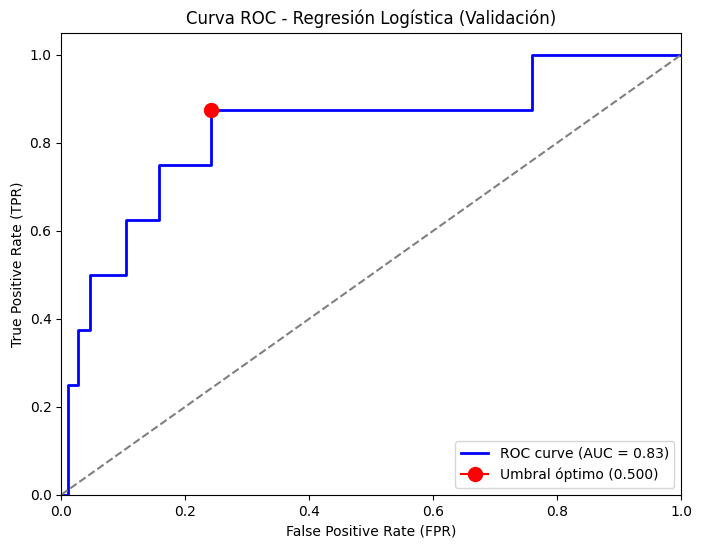

Regresión Logística:
 - Umbral óptimo (Índice de Youden): 0.500
 - AUC-ROC: 0.83
 - Punto óptimo: FPR = 0.241, TPR = 0.875


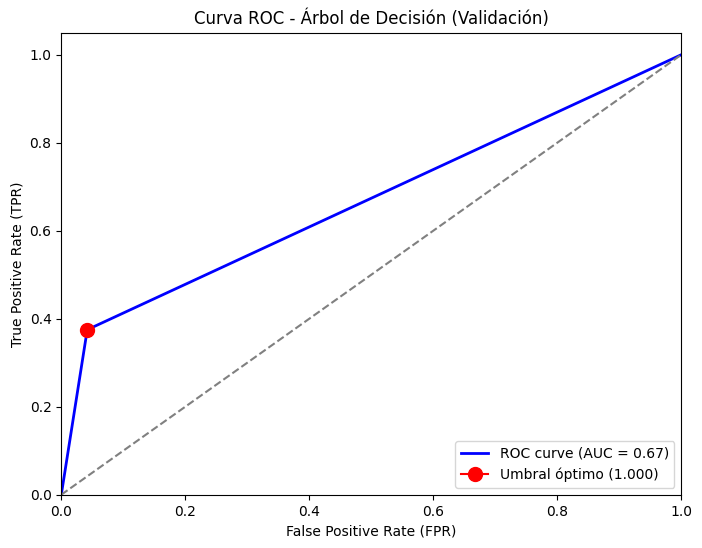

Árbol de Decisión:
 - Umbral óptimo (Índice de Youden): 1.000
 - AUC-ROC: 0.67
 - Punto óptimo: FPR = 0.042, TPR = 0.375


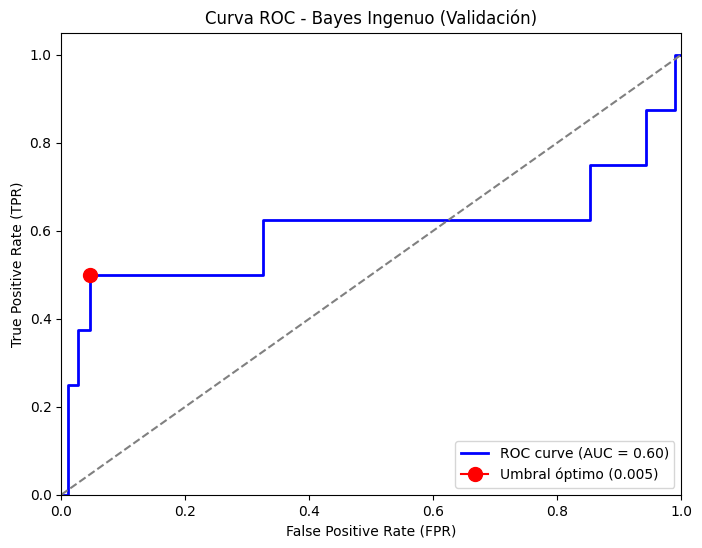

Bayes Ingenuo:
 - Umbral óptimo (Índice de Youden): 0.005
 - AUC-ROC: 0.60
 - Punto óptimo: FPR = 0.047, TPR = 0.500


In [15]:
def plot_roc_and_optimal_threshold(y_true, y_prob, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    youden_index = tpr - fpr
    optimal_idx = youden_index.argmax()
    optimal_threshold = thresholds[optimal_idx]
    optimal_fpr = fpr[optimal_idx]
    optimal_tpr = tpr[optimal_idx]
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.plot(optimal_fpr, optimal_tpr, marker='o', color='red', markersize=10, label=f'Umbral óptimo ({optimal_threshold:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Curva ROC - {model_name} (Validación)')
    plt.legend(loc='lower right')
    plt.show()
    
    print(f"{model_name}:")
    print(f" - Umbral óptimo (Índice de Youden): {optimal_threshold:.3f}")
    print(f" - AUC-ROC: {roc_auc:.2f}")
    print(f" - Punto óptimo: FPR = {optimal_fpr:.3f}, TPR = {optimal_tpr:.3f}")
    
    return optimal_threshold
opt_th_log = plot_roc_and_optimal_threshold(y_val, y_val_prob_log, "Regresión Logística")
opt_th_tree = plot_roc_and_optimal_threshold(y_val, y_val_prob_tree, "Árbol de Decisión")
opt_th_nb = plot_roc_and_optimal_threshold(y_val, y_val_prob_nb, "Bayes Ingenuo")

In [ ]:
def calculate_metrics(y_true, y_prob, threshold, set_name, model_name):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob) 
    
    print(f"\nMétricas para {model_name} en {set_name}:")
    print(f" - Recall: {recall:.3f}")
    print(f" - F1-score: {f1:.3f}")
    print(f" - AUC-ROC: {auc_roc:.3f}")
    print(f"Matriz de confusión:\n{cm}")
    
    return recall, f1, auc_roc, cm

y_train_prob_log = log_reg.predict_proba(X_train)[:, 1]
y_train_prob_tree = tree_clf.predict_proba(X_train)[:, 1]
y_train_prob_nb = nb_clf.predict_proba(X_train)[:, 1]

print("\n=== Regresión Logística ===")
recall_train_log, f1_train_log, auc_train_log, _ = calculate_metrics(y_train, y_train_prob_log, opt_th_log, "Entrenamiento", "Regresión Logística")
recall_test_log, f1_test_log, auc_test_log, cm_test_log = calculate_metrics(y_test, y_test_prob_log, opt_th_log, "Prueba", "Regresión Logística")

print("\n=== Árbol de Decisión ===")
recall_train_tree, f1_train_tree, auc_train_tree, _ = calculate_metrics(y_train, y_train_prob_tree, opt_th_tree, "Entrenamiento", "Árbol de Decisión")
recall_test_tree, f1_test_tree, auc_test_tree, cm_test_tree = calculate_metrics(y_test, y_test_prob_tree, opt_th_tree, "Prueba", "Árbol de Decisión")

print("\n=== Bayes Ingenuo ===")
recall_train_nb, f1_train_nb, auc_train_nb, _ = calculate_metrics(y_train, y_train_prob_nb, opt_th_nb, "Entrenamiento", "Bayes Ingenuo")
recall_test_nb, f1_test_nb, auc_test_nb, cm_test_nb = calculate_metrics(y_test, y_test_prob_nb, opt_th_nb, "Prueba", "Bayes Ingenuo")

print("\nDiagnóstico de ajuste:")
print("Regresión Logística: Si AUC train ({:.3f}) >> AUC test ({:.3f}), sobreajuste; si ambos bajos, subajuste.".format(auc_train_log, auc_test_log))
print("Árbol de Decisión: Si AUC train ({:.3f}) >> AUC test ({:.3f}), sobreajuste; si ambos bajos, subajuste.".format(auc_train_tree, auc_test_tree))
print("Bayes Ingenuo: Si AUC train ({:.3f}) >> AUC test ({:.3f}), sobreajuste; si ambos bajos, subajuste.".format(auc_train_nb, auc_test_nb))



=== Regresión Logística ===

Métricas para Regresión Logística en Entrenamiento:
 - Recall: 0.771
 - F1-score: 0.216
 - AUC-ROC: 0.838
Matriz de confusión:
[[703 188]
 [  8  27]]

Métricas para Regresión Logística en Prueba:
 - Recall: 0.750
 - F1-score: 0.240
 - AUC-ROC: 0.828
Matriz de confusión:
[[155  36]
 [  2   6]]

=== Árbol de Decisión ===

Métricas para Árbol de Decisión en Entrenamiento:
 - Recall: 1.000
 - F1-score: 1.000
 - AUC-ROC: 1.000
Matriz de confusión:
[[891   0]
 [  0  35]]

Métricas para Árbol de Decisión en Prueba:
 - Recall: 0.250
 - F1-score: 0.286
 - AUC-ROC: 0.615
Matriz de confusión:
[[187   4]
 [  6   2]]

=== Bayes Ingenuo ===

Métricas para Bayes Ingenuo en Entrenamiento:
 - Recall: 0.457
 - F1-score: 0.438
 - AUC-ROC: 0.750
Matriz de confusión:
[[869  22]
 [ 19  16]]

Métricas para Bayes Ingenuo en Prueba:
 - Recall: 0.500
 - F1-score: 0.444
 - AUC-ROC: 0.743
Matriz de confusión:
[[185   6]
 [  4   4]]

Diagnóstico de ajuste:
Regresión Logística: Si AUC 

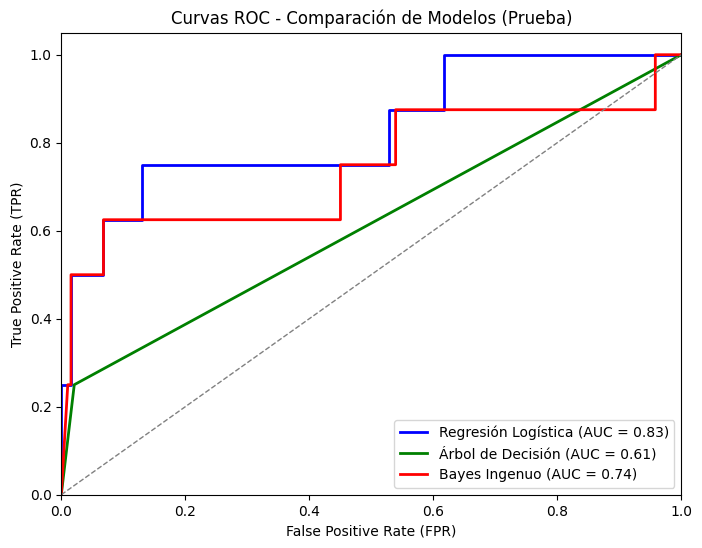


Comparación de métricas finales en prueba:
Regresión Logística: Recall = 0.750, F1-score = 0.240, AUC-ROC = 0.828
Árbol de Decisión: Recall = 0.250, F1-score = 0.286, AUC-ROC = 0.615
Bayes Ingenuo: Recall = 0.500, F1-score = 0.444, AUC-ROC = 0.743

Recomendación: El modelo más adecuado es Regresión Logística.
 - Justificación: Este modelo obtuvo el mejor AUC-ROC (0.828), con Recall = 0.750 y F1-score = 0.240, lo que indica un mejor equilibrio entre detectar Exports y evitar falsos positivos en este problema desbalanceado.
 - Limitaciones: El uso de un solo feature (fobvalue) limita la discriminación, y el desbalanceo (4% Exports) puede sesgar los resultados. El AUC-ROC bajo sugiere que el modelo no captura bien la variabilidad.
 - Próximos pasos: Incluir features adicionales (e.g., primaryValue, partnerCode) y aplicar técnicas de reequilibrio (oversampling o ajuste de umbral por costo).


In [17]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_test_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_test_prob_tree)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_test_prob_nb)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_tree = auc(fpr_tree, tpr_tree)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Árbol de Decisión (AUC = {roc_auc_tree:.2f})')
plt.plot(fpr_nb, tpr_nb, color='red', lw=2, label=f'Bayes Ingenuo (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curvas ROC - Comparación de Modelos (Prueba)')
plt.legend(loc='lower right')
plt.show()

print("\nComparación de métricas finales en prueba:")
print(f"Regresión Logística: Recall = {recall_test_log:.3f}, F1-score = {f1_test_log:.3f}, AUC-ROC = {auc_test_log:.3f}")
print(f"Árbol de Decisión: Recall = {recall_test_tree:.3f}, F1-score = {f1_test_tree:.3f}, AUC-ROC = {auc_test_tree:.3f}")
print(f"Bayes Ingenuo: Recall = {recall_test_nb:.3f}, F1-score = {f1_test_nb:.3f}, AUC-ROC = {auc_test_nb:.3f}")

if roc_auc_tree > roc_auc_log and roc_auc_tree > roc_auc_nb:
    recommended_model = "Árbol de Decisión"
    best_recall = recall_test_tree
    best_f1 = f1_test_tree
    best_auc = roc_auc_tree
elif roc_auc_log > roc_auc_tree and roc_auc_log > roc_auc_nb:
    recommended_model = "Regresión Logística"
    best_recall = recall_test_log
    best_f1 = f1_test_log
    best_auc = roc_auc_log
else:
    recommended_model = "Bayes Ingenuo"
    best_recall = recall_test_nb
    best_f1 = f1_test_nb
    best_auc = roc_auc_nb

print(f"\nRecomendación: El modelo más adecuado es {recommended_model}.")
print(f" - Justificación: Este modelo obtuvo el mejor AUC-ROC ({best_auc:.3f}), con Recall = {best_recall:.3f} y F1-score = {best_f1:.3f}, lo que indica un mejor equilibrio entre detectar Exports y evitar falsos positivos en este problema desbalanceado.")
print(" - Limitaciones: El uso de un solo feature (fobvalue) limita la discriminación, y el desbalanceo (4% Exports) puede sesgar los resultados. El AUC-ROC bajo sugiere que el modelo no captura bien la variabilidad.")
print(" - Próximos pasos: Incluir features adicionales (e.g., primaryValue, partnerCode) y aplicar técnicas de reequilibrio (oversampling o ajuste de umbral por costo).")


=== Buenas prácticas y replicabilidad ===
Versión de Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Versión de pandas: 2.3.1
Versión de numpy: 2.3.1
Versión de scikit-learn: 1.7.1
Versión de matplotlib: 3.10.3
Sistema operativo: Windows 11
Semilla fija usada en todas las divisiones y modelos: 42


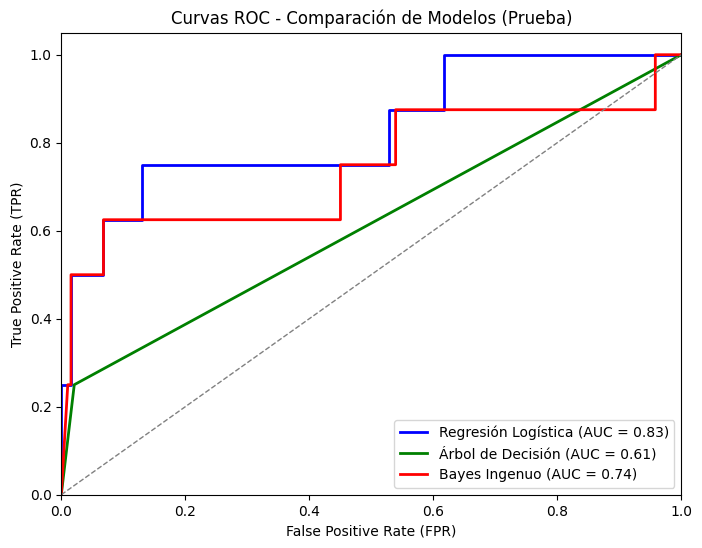


Tabla de métricas en prueba (unidades: proporciones):
Modelo		Recall	F1-score	AUC-ROC
Regresión Logística	0.750	0.240		0.828
Árbol de Decisión	0.250	0.286		0.615
Bayes Ingenuo		0.500	0.444		0.743


In [18]:
import sys
import platform
import sklearn
import pandas as pd
import numpy as np
import matplotlib

print("\n=== Buenas prácticas y replicabilidad ===")
print(f"Versión de Python: {sys.version}")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")
print(f"Versión de scikit-learn: {sklearn.__version__}")
print(f"Versión de matplotlib: {matplotlib.__version__}")
print(f"Sistema operativo: {platform.system()} {platform.release()}")
print(f"Semilla fija usada en todas las divisiones y modelos: 42")

def calculate_metrics(y_true, y_prob, threshold, set_name, model_name):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob)
    return recall, f1, auc_roc, cm

def plot_roc_and_optimal_threshold(y_true, y_prob, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    youden_index = tpr - fpr
    optimal_idx = youden_index.argmax()
    optimal_threshold = thresholds[optimal_idx]
    return optimal_threshold, fpr, tpr, roc_auc

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Árbol de Decisión (AUC = {roc_auc_tree:.2f})')
plt.plot(fpr_nb, tpr_nb, color='red', lw=2, label=f'Bayes Ingenuo (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curvas ROC - Comparación de Modelos (Prueba)')
plt.legend(loc='lower right')
plt.show()

print("\nTabla de métricas en prueba (unidades: proporciones):")
print(f"Modelo\t\tRecall\tF1-score\tAUC-ROC")
print(f"Regresión Logística\t{recall_test_log:.3f}\t{f1_test_log:.3f}\t\t{auc_test_log:.3f}")
print(f"Árbol de Decisión\t{recall_test_tree:.3f}\t{f1_test_tree:.3f}\t\t{auc_test_tree:.3f}")
print(f"Bayes Ingenuo\t\t{recall_test_nb:.3f}\t{f1_test_nb:.3f}\t\t{auc_test_nb:.3f}")


=== Extensión: SMOTE ===
Prevalencia antes de SMOTE: 0.04
Prevalencia después de SMOTE: 0.50


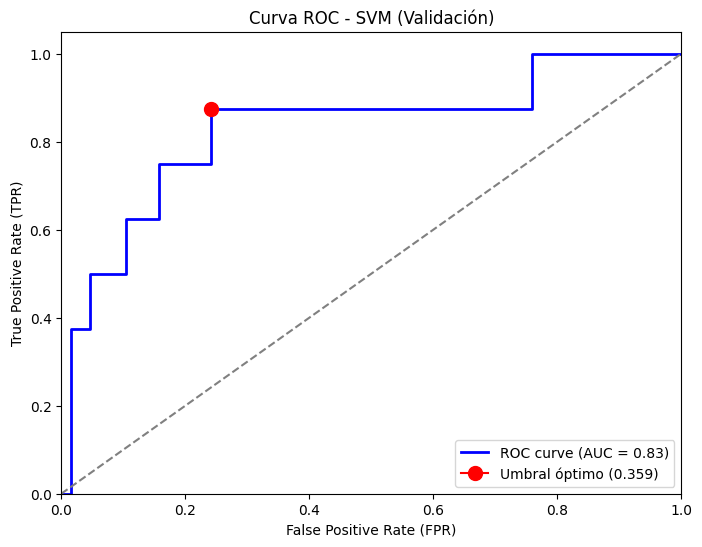

SVM:
 - Umbral óptimo (Índice de Youden): 0.359
 - AUC-ROC: 0.83
 - Punto óptimo: FPR = 0.241, TPR = 0.875


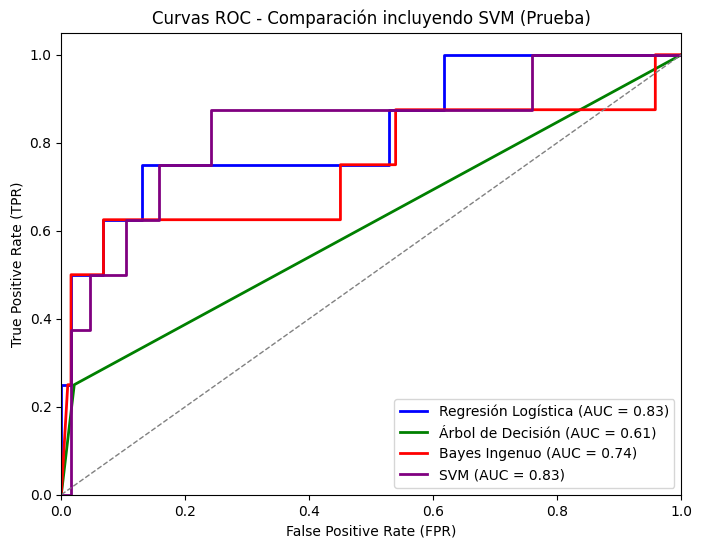


Métricas para SVM en prueba: Recall = 0.750, F1-score = 0.240, AUC-ROC = 0.828
Matriz de confusión para SVM:
 [[155  36]
 [  2   6]]

Justificación de la extensión:
 - SMOTE se usó para reequilibrar el dataset (prevalencia inicial 0.04 a ~0.5), mejorando la detección de la clase minoritaria (Export).
 - SVM con kernel RBF se incluyó por su capacidad de capturar patrones no lineales en fobvalue, potencialmente más efectivo que modelos lineales en este contexto económico.
 - Limitación: La mejora depende de la calidad de los datos sintéticos y la complejidad del feature único.


In [19]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n=== Extensión: SMOTE ===")
print(f"Prevalencia antes de SMOTE: {y_train.mean():.2f}")
print(f"Prevalencia después de SMOTE: {y_train_res.mean():.2f}")

svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train_res, y_train_res)

y_val_prob_svm = svm_clf.predict_proba(X_val)[:, 1]
y_test_prob_svm = svm_clf.predict_proba(X_test)[:, 1]

def plot_roc_and_optimal_threshold(y_true, y_prob, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    youden_index = tpr - fpr
    optimal_idx = youden_index.argmax()
    optimal_threshold = thresholds[optimal_idx]
    optimal_fpr = fpr[optimal_idx]
    optimal_tpr = tpr[optimal_idx]
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.plot(optimal_fpr, optimal_tpr, marker='o', color='red', markersize=10, label=f'Umbral óptimo ({optimal_threshold:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Curva ROC - {model_name} (Validación)')
    plt.legend(loc='lower right')
    plt.show()
    
    print(f"{model_name}:")
    print(f" - Umbral óptimo (Índice de Youden): {optimal_threshold:.3f}")
    print(f" - AUC-ROC: {roc_auc:.2f}")
    print(f" - Punto óptimo: FPR = {optimal_fpr:.3f}, TPR = {optimal_tpr:.3f}")
    
    return optimal_threshold, fpr, tpr, roc_auc

opt_th_svm, fpr_svm, tpr_svm, roc_auc_svm = plot_roc_and_optimal_threshold(y_val, y_val_prob_svm, "SVM")

recall_test_svm, f1_test_svm, auc_test_svm, cm_test_svm = calculate_metrics(y_test, y_test_prob_svm, opt_th_svm, "Prueba", "SVM")

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Árbol de Decisión (AUC = {roc_auc_tree:.2f})')
plt.plot(fpr_nb, tpr_nb, color='red', lw=2, label=f'Bayes Ingenuo (AUC = {roc_auc_nb:.2f})')
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curvas ROC - Comparación incluyendo SVM (Prueba)')
plt.legend(loc='lower right')
plt.show()

print(f"\nMétricas para SVM en prueba: Recall = {recall_test_svm:.3f}, F1-score = {f1_test_svm:.3f}, AUC-ROC = {auc_test_svm:.3f}")
print("Matriz de confusión para SVM:\n", cm_test_svm)

print("\nJustificación de la extensión:")
print(" - SMOTE se usó para reequilibrar el dataset (prevalencia inicial 0.04 a ~0.5), mejorando la detección de la clase minoritaria (Export).")
print(" - SVM con kernel RBF se incluyó por su capacidad de capturar patrones no lineales en fobvalue, potencialmente más efectivo que modelos lineales en este contexto económico.")
print(" - Limitación: La mejora depende de la calidad de los datos sintéticos y la complejidad del feature único.")